# Model Results — Social Media Emotion Analyzer
### SAIA 2163 · Final Project · Theme 5

This notebook presents the **final results** of the trained emotion-classification
models. Unlike `emotion_analysis.ipynb` (which trains everything from scratch),
this notebook **loads the saved artifacts** and focuses purely on reporting:

1. Metrics table for all five model/feature combinations
2. Accuracy vs F1 comparison chart
3. Confusion matrix of the deployed model
4. Per-emotion classification report
5. Live prediction demo on new sentences

**Deployed model:** Logistic Regression + TF-IDF — **90.0% accuracy / 0.90 F1**
on 2,000 held-out test messages.

> **Running in Google Colab?** Just run the cells in order. Cell 1 will ask you to
> upload the 5 model files from your `models/` folder if it can't find them:
> `best_model.pkl`, `tfidf_vectorizer.pkl`, `all_results.json`,
> `confusion_matrix.json`, `app_metrics.json`.

## 1 · Setup & load saved artifacts

We locate the trained model, the TF-IDF vectorizer, and the metrics JSON files
produced by `train_models.py`. This works whether you run from the `notebooks/`
folder, the project root, or Google Colab (where it will prompt for an upload).

In [1]:
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

LABEL_MAP = {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}
ORDER = ['joy', 'sadness', 'love', 'anger', 'fear', 'surprise']
COLORS = {'joy': '#5E8C1E', 'sadness': '#2F7BC4', 'love': '#C9456F',
          'anger': '#C9501F', 'fear': '#168A66', 'surprise': '#6A5FC9'}

NEEDED = ['best_model.pkl', 'tfidf_vectorizer.pkl', 'all_results.json',
          'confusion_matrix.json', 'app_metrics.json']

def _find_models_dir():
    """Look for a folder that contains all the needed artifacts."""
    for base in ['models', '../models', '../../models', 'emotion_project/models', '.']:
        if all(os.path.exists(os.path.join(base, f)) for f in NEEDED):
            return base
    return None

MODELS = _find_models_dir()

if MODELS is None:
    # Not found locally -> if we're in Colab, ask the user to upload the files.
    try:
        from google.colab import files
        print('Model files not found. Please upload these 5 files from your models/ folder:')
        print('   ' + ', '.join(NEEDED) + '\n')
        os.makedirs('models', exist_ok=True)
        uploaded = files.upload()
        for fn in list(uploaded):
            os.replace(fn, os.path.join('models', fn))
        MODELS = 'models'
    except ImportError:
        raise FileNotFoundError(
            'Could not find the models/ folder. Run this notebook from inside the '
            'project notebooks/ folder, or upload the 5 model files listed above.')

model = joblib.load(os.path.join(MODELS, 'best_model.pkl'))
tfidf = joblib.load(os.path.join(MODELS, 'tfidf_vectorizer.pkl'))
with open(os.path.join(MODELS, 'all_results.json')) as f:
    results = json.load(f)
with open(os.path.join(MODELS, 'confusion_matrix.json')) as f:
    cm_data = json.load(f)
with open(os.path.join(MODELS, 'app_metrics.json')) as f:
    app_metrics = json.load(f)

print('\nArtifacts loaded successfully.')
print('Using models dir:', os.path.abspath(MODELS))
print('Deployed model  :', type(model).__name__)
print('TF-IDF features :', len(tfidf.get_feature_names_out()))


Artifacts loaded successfully.
Using models dir: C:\Users\User\Downloads\emotion_analyzer_project\emotion_project\models
Deployed model  : LogisticRegression
TF-IDF features : 8000


## 2 · Results table — all models

Every model was evaluated on the **same untouched 2,000-message test set**.

In [2]:
res = pd.DataFrame(results)
res_display = res.copy()
for col in ['accuracy', 'precision', 'recall', 'f1']:
    res_display[col] = (res_display[col] * 100).round(1).astype(str) + '%'
res_display.columns = ['Model', 'Features', 'Accuracy', 'Precision', 'Recall', 'F1-score']
res_display

,Model,Features,Accuracy,Precision,Recall,F1-score
0,Naive Bayes,TF-IDF,79.2%,82.6%,79.2%,76.4%
1,Logistic Reg,TF-IDF,89.9%,90.6%,89.9%,90.1%
2,Linear SVM,TF-IDF,90.1%,90.5%,90.1%,90.3%
3,Logistic Reg,Word2Vec,42.5%,50.6%,42.5%,44.7%
4,Linear SVM,Word2Vec,48.3%,49.1%,48.3%,48.4%


In [3]:
best = max(results, key=lambda r: r['f1'])
print(f"Best by F1   : {best['model']} [{best['feature']}]  ->  F1 = {best['f1']:.4f}")
print(f"Deployed app : Logistic Regression [TF-IDF]  ->  "
      f"acc = {app_metrics['accuracy']:.4f}, f1 = {app_metrics['f1']:.4f}")
print('\nNote: Logistic Regression is deployed (rather than the marginally higher SVM)')
print('because it outputs calibrated probabilities for the confidence bars in the app.')

Best by F1   : Linear SVM [TF-IDF]  ->  F1 = 0.9026
Deployed app : Logistic Regression [TF-IDF]  ->  acc = 0.8990, f1 = 0.9010

Note: Logistic Regression is deployed (rather than the marginally higher SVM)
because it outputs calibrated probabilities for the confidence bars in the app.


## 3 · Model comparison chart

Accuracy and F1 side by side. The gap between TF-IDF and Word2Vec is striking.

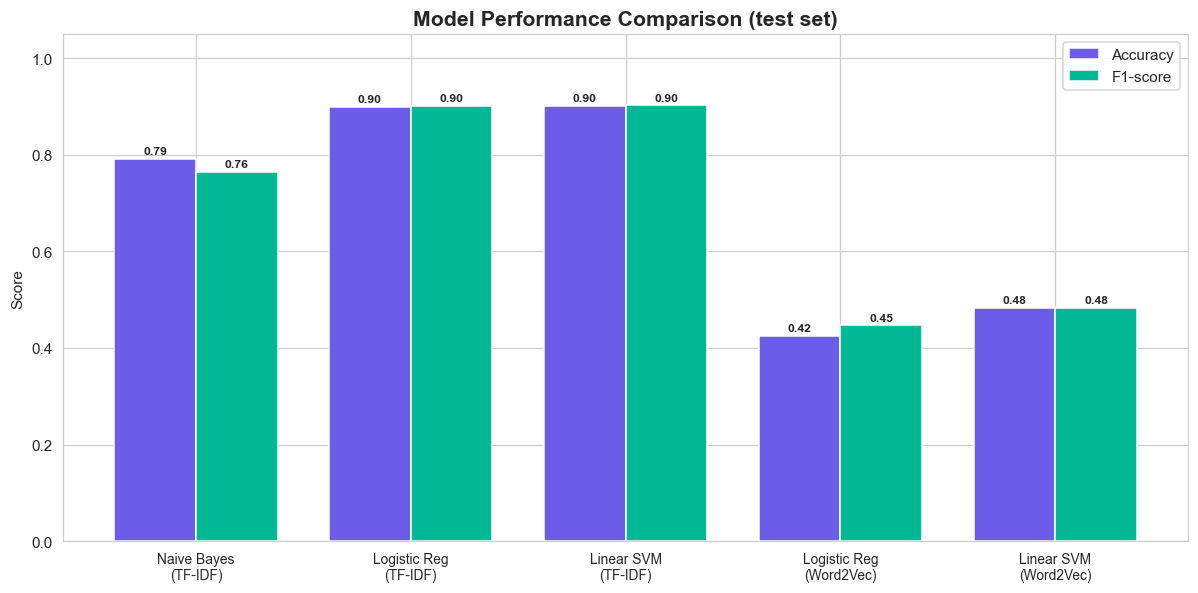

In [4]:
res['label'] = res['model'] + '\n(' + res['feature'] + ')'
x = np.arange(len(res))
w = 0.38
fig, ax = plt.subplots(figsize=(11, 5.5))
b1 = ax.bar(x - w/2, res['accuracy'], w, label='Accuracy', color='#6C5CE7')
b2 = ax.bar(x + w/2, res['f1'], w, label='F1-score', color='#00B894')
ax.set_xticks(x)
ax.set_xticklabels(res['label'], fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison (test set)', fontsize=14, fontweight='bold')
ax.legend()
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                f'{b.get_height():.2f}', ha='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.show()

**Finding:** TF-IDF (~90% accuracy) vastly outperforms averaged Word2Vec (~42-49%).
Social-media messages are short, so averaging word vectors blurs the signal,
while TF-IDF preserves the strong emotion keywords directly.

## 4 · Confusion matrix — deployed model

Rows = true emotion, columns = predicted. Counts are annotated; colour shows
the normalised proportion per row.

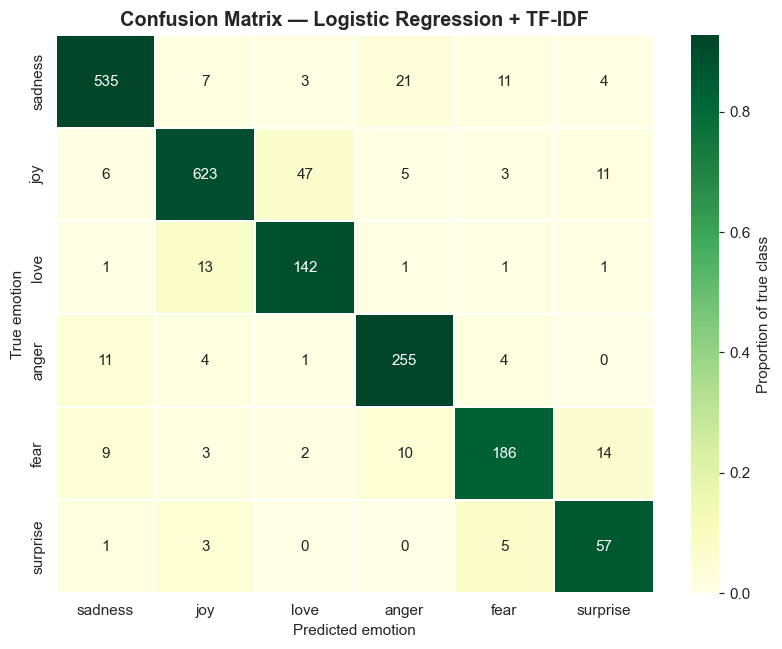

In [5]:
cm = np.array(cm_data['matrix'])
names = cm_data['labels']
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(7.5, 6))
sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='YlGn',
            xticklabels=names, yticklabels=names,
            cbar_kws={'label': 'Proportion of true class'},
            linewidths=1, linecolor='white')
plt.title('Confusion Matrix — Logistic Regression + TF-IDF',
          fontsize=13, fontweight='bold')
plt.xlabel('Predicted emotion')
plt.ylabel('True emotion')
plt.tight_layout()
plt.show()

## 5 · Per-emotion classification report

We re-derive precision / recall / F1 for each of the six emotions directly from
the saved confusion matrix (no re-training needed).

In [6]:
rows = []
for i, name in enumerate(names):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    support = cm[i, :].sum()
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    rows.append({'Emotion': name, 'Precision': round(precision, 3),
                 'Recall': round(recall, 3), 'F1-score': round(f1, 3),
                 'Support': int(support)})

report = pd.DataFrame(rows)
overall_acc = np.trace(cm) / cm.sum()
print(f'Overall accuracy: {overall_acc:.4f}  ({int(np.trace(cm))} / {int(cm.sum())} correct)\n')
report

Overall accuracy: 0.8990  (1798 / 2000 correct)



,Emotion,Precision,Recall,F1-score,Support
0,sadness,0.950,0.921,0.935,581
1,joy,0.954,0.896,0.924,695
2,love,0.728,0.893,0.802,159
3,anger,0.873,0.927,0.899,275
4,fear,0.886,0.830,0.857,224
5,surprise,0.655,0.864,0.745,66


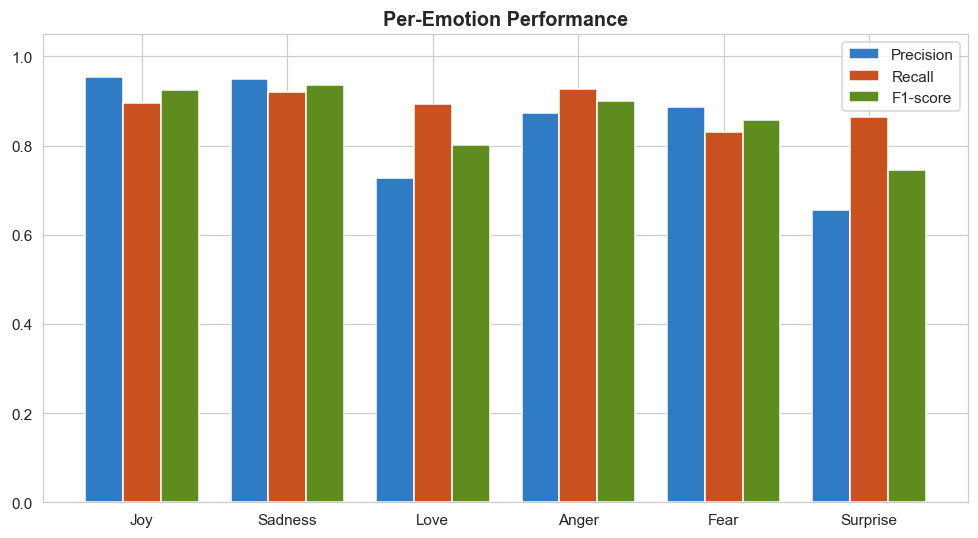

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
rep_sorted = report.set_index('Emotion').reindex(ORDER)
x = np.arange(len(rep_sorted))
w = 0.26
ax.bar(x - w, rep_sorted['Precision'], w, label='Precision', color='#2F7BC4')
ax.bar(x, rep_sorted['Recall'], w, label='Recall', color='#C9501F')
ax.bar(x + w, rep_sorted['F1-score'], w, label='F1-score', color='#5E8C1E')
ax.set_xticks(x)
ax.set_xticklabels([e.capitalize() for e in rep_sorted.index])
ax.set_ylim(0, 1.05)
ax.set_title('Per-Emotion Performance', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

**Observation:** *Joy*, *sadness*, and *anger* score highest. *Surprise* is the
hardest class — it is rare in the data and overlaps semantically with joy and fear.

## 6 · Live prediction demo

Finally, we run the deployed model on a few fresh sentences to confirm it behaves
as expected end-to-end. We use the same cleaning steps as training — importing
`preprocess.py` if available, otherwise defining `clean_text` inline so this
cell also works in Colab.

In [8]:
import re
try:
    import sys
    sys.path.append('..'); sys.path.append('.')
    from preprocess import clean_text
    print('Using clean_text from preprocess.py')
except Exception:
    import nltk
    from nltk.corpus import stopwords
    from nltk.stem import WordNetLemmatizer
    for p in ['stopwords', 'wordnet', 'omw-1.4']:
        nltk.download(p, quiet=True)
    _lem = WordNetLemmatizer()
    _stop = set(stopwords.words('english')) - {'no', 'nor', 'not', 'never', 'none', 'cannot'}

    def clean_text(t):
        t = re.sub(r'http\S+|www\.\S+', ' ', str(t).lower())
        t = re.sub(r'[^a-z\s]', ' ', t)
        return ' '.join(_lem.lemmatize(w) for w in t.split() if w not in _stop and len(w) > 1)
    print('Using inline clean_text (preprocess.py not found)')


def predict_emotion(text):
    cleaned = clean_text(text)
    X = tfidf.transform([cleaned])
    probs = model.predict_proba(X)[0]
    order = [LABEL_MAP[c] for c in model.classes_]
    return sorted(zip(order, probs), key=lambda p: -p[1])


samples = [
    'i feel so happy and grateful for everything today',
    'i am terrified about what might happen tomorrow',
    'i cant believe they actually did that, totally shocked',
    'i am so angry that they lied to me again',
    'i miss them so much it hurts my heart',
]

for s in samples:
    top_emotion, top_prob = predict_emotion(s)[0]
    print(f'"{s}"')
    print(f'   -> {top_emotion.upper():<10} ({top_prob*100:.1f}% confidence)\n')

Using clean_text from preprocess.py


"i feel so happy and grateful for everything today"
   -> JOY        (93.9% confidence)

"i am terrified about what might happen tomorrow"
   -> FEAR       (97.6% confidence)

"i cant believe they actually did that, totally shocked"
   -> SURPRISE   (97.6% confidence)

"i am so angry that they lied to me again"
   -> ANGER      (97.9% confidence)

"i miss them so much it hurts my heart"
   -> SADNESS    (76.5% confidence)



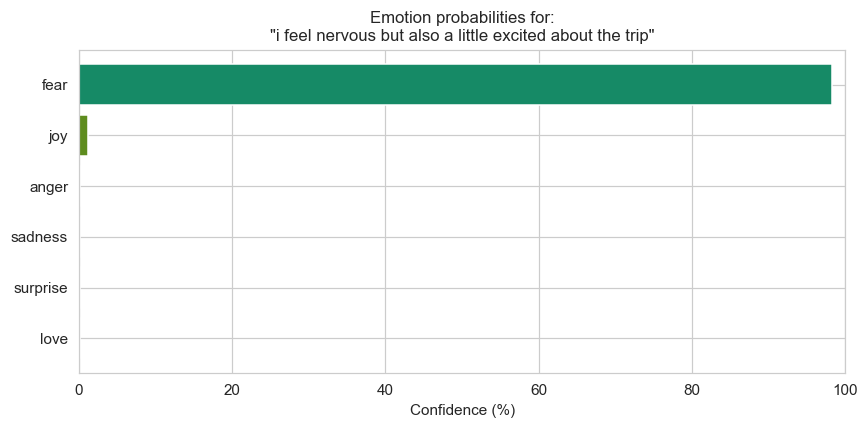

In [9]:
# Visualise the full probability distribution for one example
example = 'i feel nervous but also a little excited about the trip'
ranked = predict_emotion(example)
emotions = [e for e, _ in ranked]
probs = [p for _, p in ranked]

plt.figure(figsize=(8, 4))
plt.barh(emotions[::-1], [p * 100 for p in probs[::-1]],
         color=[COLORS[e] for e in emotions[::-1]])
plt.xlabel('Confidence (%)')
plt.title(f'Emotion probabilities for:\n"{example}"', fontsize=11)
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

## 7 · Summary

| Metric | Value |
|--------|-------|
| Deployed model | Logistic Regression + TF-IDF |
| Test accuracy | **90.0%** |
| Weighted F1 | **0.90** |
| Weighted precision | 0.91 |
| Weighted recall | 0.90 |
| Test set size | 2,000 messages |
| Emotions | 6 (joy, sadness, love, anger, fear, surprise) |

The deployed model reaches the top of the field on this dataset while also
providing calibrated confidence scores, which is why it powers the live
Streamlit app (`app.py`). The weakest class is *surprise* — a candidate for
future improvement via class re-balancing (e.g. SMOTE) or transformer embeddings.